<img src="https://upload.wikimedia.org/wikipedia/commons/c/cc/Uber_logo_2018.png" alt="UBER" width="150" />

# Where should the drivers be?

Uber's product team wants the app to **recommend hot zones to drivers, in a major city, at any
given time of day.** The reason is a number from their own research: a rider accepts a wait of
**5 to 7 minutes** and cancels beyond it. A driver in the Castro is useless to a rider in the
Financial District.

This notebook builds those zones for New York, from 4.5 million pickups. It answers the three
things the brief asks for — a map, a description **per day of week**, and a comparison of **two
unsupervised algorithms** — and two of the three answers are not the expected ones:

> **The day of week is the weak axis.** The map of demand moves twice as much between two hours of
> the same day as between two days of the week. Two *adjacent* hours differ almost as much as an
> average pair of days.
>
> **DBSCAN cannot answer this question, and the reason is interesting.** It looks for zones
> separated by empty space; Manhattan has none. At every parameter setting it returns one cluster
> holding three quarters of the city, or throws away a third of the demand as noise.

Everything below is the evidence for those sentences.

---

### How this notebook is organised

| Section | What it does |
|---|---|
| 1 | Load the pickups and establish what one row is |
| 2 | What looks like cleaning here — and what each rule would cost |
| 3 | Where the demand is, and when |
| 4 | Hot zones with KMeans — how many, where, and how stable |
| 5 | Hot zones with DBSCAN — and what the comparison really says |
| 6 | Do the zones move with the day of week? |
| 7 | What Uber should ship |

Every claim below is the output of the cell above it.

## 1. The pickups

In [1]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

# Plotly figures are rendered as static images rather than interactive widgets.
# Reason: this notebook is the deliverable and has to stay readable wherever it is opened.
# GitHub, nbviewer and PDF exports all strip interactive plotly output and would show nothing.
# The maps still need a network connection when they are rendered: the basemap tiles are fetched
# from CARTO / OpenStreetMap at render time.
pio.renderers.default = 'png'

# Charts are also written to disk, so the README and the oral presentation can reuse them.
IMAGES = Path('images')
IMAGES.mkdir(exist_ok=True)

# One seed for the whole notebook: every KMeans fit, every DBSCAN sample and the stability study
# in section 4.4 read it, so every number below is reproducible from this line.
RANDOM_STATE = 42

# The palette: one blue for a single measure, blue/red when a chart carries a contrast.
BLUE, RED, GREY = '#2a78d6', '#e34948', '#8a8a85'


def show(fig, name, height=520):
    """Render a figure in the notebook and save it as a PNG under images/."""
    fig.update_layout(width=980, height=height, template='plotly_white',
                      margin=dict(t=80, b=60, l=70, r=40))
    fig.write_image(IMAGES / f'{name}.png', scale=2)
    fig.show()

In [2]:
FILES = sorted(Path('data/uber-trip-data').glob('uber-raw-data-*14.csv'))
raw = pd.concat([pd.read_csv(f) for f in FILES], ignore_index=True)

print(f'{len(FILES)} monthly files -> {len(raw):,} pickups x {raw.shape[1]} columns'.replace(',', ' '))
raw.head()

6 monthly files -> 4 534 327 pickups x 4 columns


,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


### What is one row, and what is in the archive

**One row is one pickup**: the minute it happened, where it happened, and the Uber base that
dispatched it. There is no drop-off, no rider, no fare, no duration — the file is a stream of
points in space and time, which is exactly what a clustering question needs and nothing more.

The archive also contains **`uber-raw-data-janjune-15.csv.zip`**, six more months of pickups. It is
not used here, and the reason is not a preference: that file has no coordinates. It identifies a
pickup by `locationID`, a taxi-zone index — the answer to "where should the driver be" is already
pre-aggregated into somebody else's 265 zones, which is the very thing this project has to build.
The cell below shows both formats side by side.

In [3]:
with zipfile.ZipFile('data/uber-trip-data/uber-raw-data-janjune-15.csv.zip') as z:
    with z.open('uber-raw-data-janjune-15.csv') as f:
        print('2015 file :', ', '.join(pd.read_csv(f, nrows=1).columns))
print('2014 files:', ', '.join(raw.columns))

when = pd.to_datetime(raw['Date/Time'], format='%m/%d/%Y %H:%M:%S')
print(f'\nperiod   : {when.min():%d %b %Y} to {when.max():%d %b %Y}')
print(f'missing  : {raw.isna().sum().sum()}')
print(f'per month:')
print(when.dt.month.value_counts().sort_index()
      .rename(lambda m: f'  2014-{m:02d}').to_string())

2015 file : Dispatching_base_num, Pickup_date, Affiliated_base_num, locationID
2014 files: Date/Time, Lat, Lon, Base



period   : 01 Apr 2014 to 30 Sep 2014
missing  : 0
per month:
Date/Time
2014-04     564516
2014-05     652435
2014-06     663844
2014-07     796121
2014-08     829275
2014-09    1028136


Six months, **April to September 2014**, and the volume grows every single one of them: 564 516
pickups in April, **1 028 136 in September**, an 82% increase in half a year. Nothing is missing.

That growth is worth keeping in mind for the rest of the notebook: this is a market being built,
not a stable one being measured, so every share below is a share of a moving total.

## 2. What looks like cleaning here — and what it would cost

Two things in this file look like they need a rule. One of them does.

### 2.1 The 82 581 duplicated rows are two riders, not one pickup counted twice

In [4]:
groups = raw.groupby(['Date/Time', 'Lat', 'Lon', 'Base'], observed=True).size()

print(f'rows drop_duplicates() would delete : {raw.duplicated().sum():,}'.replace(',', ' '))
print(f'identical-row groups by size       :')
print(groups.value_counts().sort_index().rename(lambda n: f'  {n} identical rows').to_string())
print(f'\ndistinct minutes in the file       : {raw["Date/Time"].nunique():,}'.replace(',', ' '))
print(f'pickups per minute, city-wide      : median {raw.groupby("Date/Time").size().median():.0f}, '
      f'busiest minute {raw.groupby("Date/Time").size().max()}')
print(f'coordinate resolution              : {raw["Lat"].astype(str).str.split(".").str[1].str.len().max()} '
      f'decimals, about 11 m')

rows drop_duplicates() would delete : 82 581
identical-row groups by size       :
1 identical rows    4369343
2 identical rows      82225
3 identical rows        178

distinct minutes in the file       : 260 093


pickups per minute, city-wide      : median 16, busiest minute 97


coordinate resolution              : 4 decimals, about 11 m


A row is duplicated when two pickups share a minute, a base **and** an 11-metre square. With a
median of 16 pickups a minute across the city and 260 000 minutes in the file, that is arithmetic
rather than an error —
and the shape of it agrees: **82 225 of the 82 403 groups are pairs**, not long runs of identical
rows, which is what a broken export would produce.

The next cell settles it. If these were duplicated records, they would cluster where the export
broke. If they are coincidences, their rate should follow the density of pickups — the same
everywhere, in proportion.

In [5]:
AIRPORTS = {'JFK': (40.6413, -73.7781), 'LaGuardia': (40.7769, -73.8740), 'Newark': (40.6895, -74.1745)}
EARTH_KM, LAT0 = 6371.0, np.radians(40.75)


def to_km(lat, lon):
    """Local flat projection around New York: degrees -> kilometres, x east, y north."""
    return np.column_stack([EARTH_KM * np.cos(LAT0) * np.radians(lon), EARTH_KM * np.radians(lat)])


xy = to_km(raw['Lat'].values, raw['Lon'].values)
at_airport = np.zeros(len(raw), dtype=bool)
for name, (la, lo) in AIRPORTS.items():
    ax, ay = to_km(np.array([la]), np.array([lo]))[0]
    at_airport |= np.hypot(xy[:, 0] - ax, xy[:, 1] - ay) < 1.5

deleted = raw.duplicated().values
print(f'duplicate rate within 1.5 km of an airport (the densest spots) : '
      f'{(deleted & at_airport).sum() / at_airport.sum():.2%}')
print(f'duplicate rate everywhere else                                : '
      f'{(deleted & ~at_airport).sum() / (~at_airport).sum():.2%}')

duplicate rate within 1.5 km of an airport (the densest spots) : 1.96%
duplicate rate everywhere else                                : 1.81%


**1.96% against 1.81%** — the same rate at the two extremes of density. These are 82 581 real
pickups by 82 581 real riders, and deleting them would delete demand. They stay.

### 2.2 The 21 227 pickups outside New York, on the other hand, go

In [6]:
BOX = dict(lat=(40.45, 41.00), lon=(-74.30, -73.65))   # generous: NJ to Long Island, Newark to the Bronx
inside = (raw['Lat'].between(*BOX['lat']) & raw['Lon'].between(*BOX['lon'])).values

print(f'pickups outside the box: {(~inside).sum():,} ({(~inside).mean():.2%})'.replace(',', ' '))
far = raw[~inside]
print(f'they reach as far as   : lat {far["Lat"].min():.2f} to {far["Lat"].max():.2f}, '
      f'lon {far["Lon"].min():.2f} to {far["Lon"].max():.2f}')
spread = far.assign(la=far['Lat'].round(1), lo=far['Lon'].round(1)).groupby(['la', 'lo']).size()
print(f'they occupy            : {len(spread)} cells of ~10 km, median {spread.median():.0f} pickups each')
print('\nthe five busiest of those cells:')
print(spread.sort_values(ascending=False).head(5).rename('pickups').to_string())

df = raw[inside].copy()
df['hour'] = when[inside].dt.hour.values
df['dow'] = when[inside].dt.dayofweek.values
XY = to_km(df['Lat'].values, df['Lon'].values)
print(f'\nkept for the rest of the notebook: {len(df):,} pickups'.replace(',', ' '))

pickups outside the box: 21 227 (0.47%)
they reach as far as   : lat 39.66 to 42.12, lon -74.93 to -72.07
they occupy            : 151 cells of ~10 km, median 26 pickups each

the five busiest of those cells:
la    lo   
40.7  -73.6    3159
40.8  -73.6    1568
41.0  -73.8    1537
40.8  -73.5    1328
41.0  -73.7    1296



kept for the rest of the notebook: 4 513 100 pickups


Half a percent of the file sits **outside the city**: Long Island, Westchester, the Jersey suburbs,
one point on the Jersey shore and one in Massachusetts. They are almost certainly genuine — Uber
ran long-distance trips — but they are not what this project is about. A hot zone is a place a
driver waits in; a driver cannot wait in twelve counties.

The cost of the rule is the rule's whole justification: **0.47% of pickups, spread over 151 cells
of 10 km at a median of 26 pickups each.** Nothing that could ever be a zone leaves with them.

## 3. Where the demand is, and when

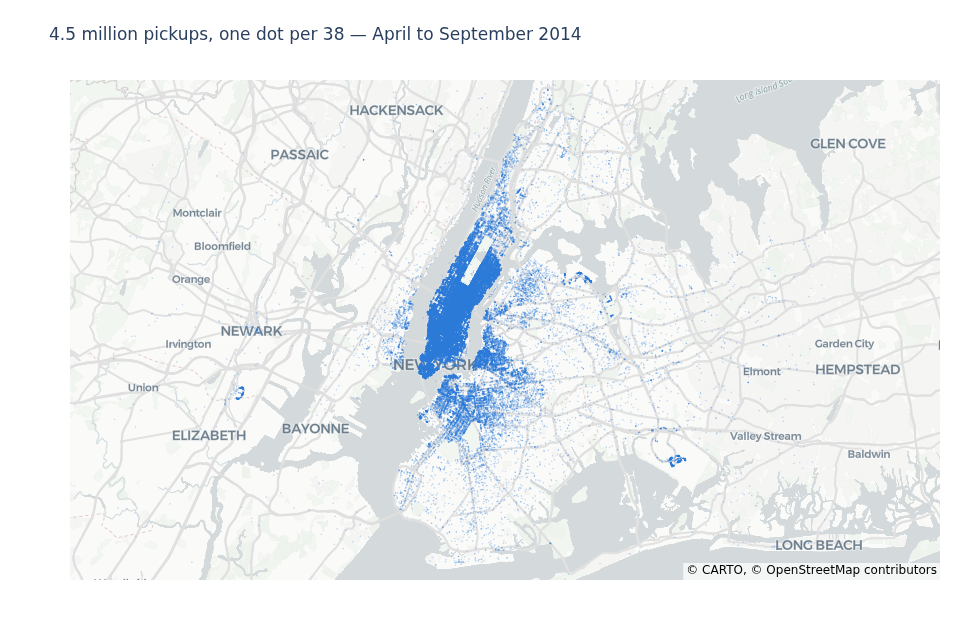

In [7]:
sample = df.sample(120_000, random_state=RANDOM_STATE)
fig = go.Figure(go.Scattermap(
    lat=sample['Lat'], lon=sample['Lon'], mode='markers',
    marker=dict(size=2.5, color=BLUE, opacity=0.25), hoverinfo='skip',
))
fig.update_layout(
    map=dict(style='carto-positron', center=dict(lat=40.735, lon=-73.94), zoom=9.6),
    title='4.5 million pickups, one dot per 38 — April to September 2014',
    showlegend=False,
)
show(fig, '1_pickups_density', height=640)

In [8]:
# How concentrated is that? Count pickups in 500 m cells.
CELL = 0.0045, 0.0059                     # ~500 m of latitude, ~500 m of longitude at 40.75 N
cell_id = (((df['Lat'] - BOX['lat'][0]) / CELL[0]).astype(int) * 100_000
           + ((df['Lon'] - BOX['lon'][0]) / CELL[1]).astype(int))
counts = cell_id.value_counts().values
covered = np.cumsum(counts) / counts.sum()

print(f'occupied 500 m cells: {len(counts)}')
for target in (0.5, 0.8, 0.9):
    print(f'cells holding {target:.0%} of all pickups: {np.searchsorted(covered, target) + 1}')

occupied 500 m cells: 6927
cells holding 50% of all pickups: 53
cells holding 80% of all pickups: 146
cells holding 90% of all pickups: 278


**53 squares of 500 metres hold half of the 4.5 million pickups**, and 146 hold 80%, out of 6 927
squares that see any pickup at all. New York's Uber demand is not spread over the city — it is a
strip of Manhattan below 96th Street, plus two airports and a slice of north Brooklyn.

That is the first reason to expect trouble from a density-based algorithm in section 5: a
concentration this smooth has no *gaps* in it.

### 3.1 The clock matters more than the map

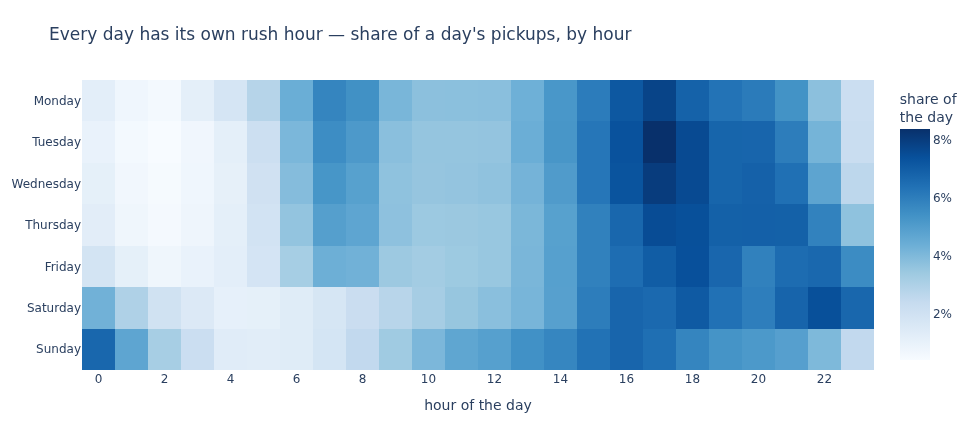

share of the week by day    : Mon 11.9%, Tue 14.7%, Wed 15.4%, Thu 16.7%, Fri 16.3%, Sat 14.2%, Sun 10.8%
busiest hour on a Wednesday : 17h (8.0% of the day)
busiest hour on a Sunday    : 16h (6.7% of the day)
Sunday 0h-2h vs Monday 0h-2h: 14.5% against 2.4% of the day


In [9]:
DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
by_hour_day = df.groupby(['dow', 'hour']).size().unstack()
share_within_day = by_hour_day.div(by_hour_day.sum(axis=1), axis=0)

fig = go.Figure(go.Heatmap(
    z=share_within_day.values, x=list(range(24)), y=DAYS,
    colorscale='Blues', colorbar=dict(title='share of<br>the day', tickformat='.0%'),
))
fig.update_layout(
    title="Every day has its own rush hour — share of a day's pickups, by hour",
    xaxis=dict(title='hour of the day', dtick=2), yaxis=dict(autorange='reversed'),
)
show(fig, '2_the_clock', height=430)

print('share of the week by day    :', ', '.join(
    f'{DAYS[d][:3]} {v:.1%}' for d, v in df['dow'].value_counts(normalize=True).sort_index().items()))
print(f'busiest hour on a Wednesday : {share_within_day.loc[2].idxmax()}h '
      f'({share_within_day.loc[2].max():.1%} of the day)')
print(f'busiest hour on a Sunday    : {share_within_day.loc[6].idxmax()}h '
      f'({share_within_day.loc[6].max():.1%} of the day)')
print(f'Sunday 0h-2h vs Monday 0h-2h: {share_within_day.loc[6, 0:2].sum():.1%} against '
      f'{share_within_day.loc[0, 0:2].sum():.1%} of the day')

Two different cities share the same map. **Monday to Friday the demand is a commute** — a bump at
7-8h and a peak at 17-18h. **Saturday and Sunday it is a night out**: the peak moves to the small
hours, and the first three hours of Sunday alone carry **14.5%** of the day against 2.4% on a
Monday.

The volume by day is much flatter than that: Thursday is the biggest day at 16.7% of the week and
Sunday the smallest at 10.8%. **The day changes when people ride, far more than how many ride** —
and section 6 asks the question this raises: does it change *where*?

## 4. Hot zones with KMeans

### 4.1 First, the coordinates have to be in metres

A degree of longitude is 84 km at this latitude and a degree of latitude is 111. Clustering the raw
`(Lon, Lat)` pairs would treat an east-west kilometre as if it were three quarters of a north-south
one — and Manhattan is a north-south island. Every fit below runs on the local projection defined
in section 2.1. The cell measures what skipping it would cost.

In [10]:
k_demo = 12
fit_km = KMeans(k_demo, n_init=5, random_state=RANDOM_STATE).fit(XY)
fit_deg = KMeans(k_demo, n_init=5, random_state=RANDOM_STATE).fit(df[['Lon', 'Lat']].values)

centres_from_deg = to_km(fit_deg.cluster_centers_[:, 1], fit_deg.cluster_centers_[:, 0])
gap = np.sqrt(((fit_km.cluster_centers_[:, None, :] - centres_from_deg[None, :, :]) ** 2).sum(-1))
nearest = gap.argmin(axis=1)

print(f'1 degree of longitude here: {EARTH_KM * np.cos(LAT0) * np.radians(1):.1f} km   '
      f'1 degree of latitude: {EARTH_KM * np.radians(1):.1f} km')
print(f'\nzone centres move by      : median {np.median(gap.min(axis=1)) * 1000:.0f} m, '
      f'up to {gap.min(axis=1).max() * 1000:.0f} m')
print(f'pickups landing in a different zone: {1 - (nearest[fit_km.labels_] == fit_deg.labels_).mean():.2%}')

1 degree of longitude here: 84.2 km   1 degree of latitude: 111.2 km

zone centres move by      : median 282 m, up to 5941 m
pickups landing in a different zone: 7.33%


Two hundred and eighty metres of error on a typical zone, six kilometres on the worst, and **7.3%
of pickups assigned to the wrong one**. On a product whose whole promise is a five-minute drive,
that is not a rounding detail.

### 4.2 How many zones? The brief already answered

There is no natural number of clusters in a continuous density — the silhouette below says so, and
the elbow of the inertia curve says nothing either. But the brief gives a criterion that does
decide: **a rider waits 5 to 7 minutes.** In city traffic that is roughly **1.5 km**, so the
question becomes: how many zones does it take before most pickups are within 1.5 km of a zone
centre?

In [11]:
K_GRID = [4, 6, 8, 10, 12, 15, 20, 25, 30, 40]
sil_sample = np.random.default_rng(RANDOM_STATE).choice(len(XY), 50_000, replace=False)

rows = []
for k in K_GRID:
    km = KMeans(k, n_init=5, random_state=RANDOM_STATE).fit(XY)
    d = np.linalg.norm(XY - km.cluster_centers_[km.labels_], axis=1)
    rows.append({'zones': k, 'median km': np.median(d), 'p90 km': np.percentile(d, 90),
                 'within 1.5 km': (d < 1.5).mean(),
                 'silhouette': silhouette_score(XY[sil_sample], km.labels_[sil_sample])})
sweep = pd.DataFrame(rows)
print(sweep.round(3).to_string(index=False))

 zones  median km  p90 km  within 1.5 km  silhouette
     4      1.998   4.524          0.331       0.425
     6      1.555   3.575          0.474       0.454
     8      1.318   3.241          0.592       0.422
    10      1.094   2.497          0.723       0.407
    12      1.058   2.220          0.751       0.411
    15      0.935   2.145          0.795       0.395
    20      0.874   1.818          0.851       0.407
    25      0.732   1.621          0.883       0.410
    30      0.639   1.370          0.916       0.400
    40      0.591   1.216          0.938       0.396


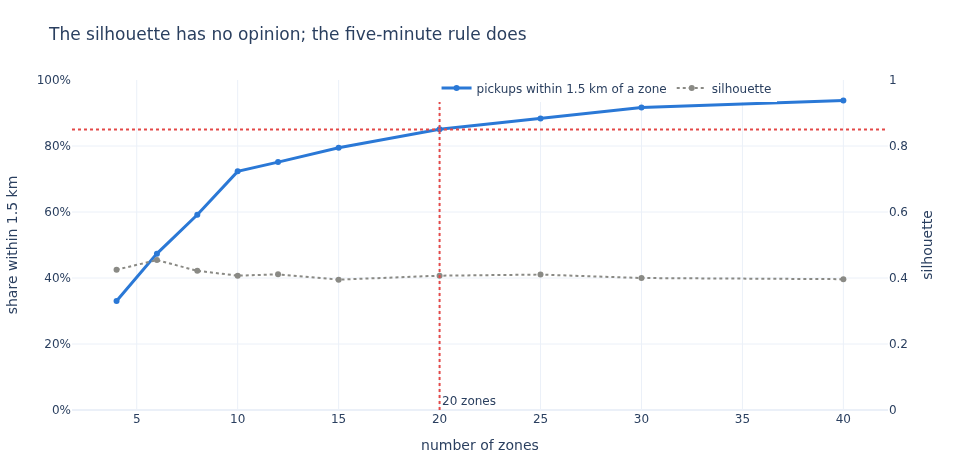

In [12]:
fig = make_subplots(specs=[[{'secondary_y': True}]])
fig.add_trace(go.Scatter(x=sweep['zones'], y=sweep['within 1.5 km'], mode='lines+markers',
                         name='pickups within 1.5 km of a zone', line=dict(color=BLUE, width=3)))
fig.add_trace(go.Scatter(x=sweep['zones'], y=sweep['silhouette'], mode='lines+markers',
                         name='silhouette', line=dict(color=GREY, width=2, dash='dot')),
              secondary_y=True)
fig.add_hline(y=0.85, line_dash='dot', line_color=RED)
fig.add_vline(x=20, line_dash='dot', line_color=RED,
              annotation_text='20 zones', annotation_position='bottom right')
fig.update_layout(
    title='The silhouette has no opinion; the five-minute rule does',
    xaxis=dict(title='number of zones'),
    legend=dict(orientation='h', y=1.02, x=0.42),
)
fig.update_yaxes(title='share within 1.5 km', tickformat='.0%', range=[0, 1], secondary_y=False)
fig.update_yaxes(title='silhouette', range=[0, 1], showgrid=False, secondary_y=True)
show(fig, '3_choosing_k', height=470)

The silhouette is flat between **0.40 and 0.45** across the whole range — it peaks at 6 zones,
which would leave a rider a median of 1.6 km and a tenth of the city more than 3.5 km from the
nearest driver. It is measuring compactness in a cloud that has no natural seams, and it should not
be allowed to choose.

The five-minute rule does choose. **20 zones put 85% of pickups within 1.5 km**, at a median of
870 m. Thirty zones would reach 92%, but a driver-facing app that lists thirty destinations for one
city is not a recommendation, it is a directory — and the gain per extra zone is already flattening.
**k = 20**, and the trade-off is on the chart rather than in a sentence.

### 4.3 The zones

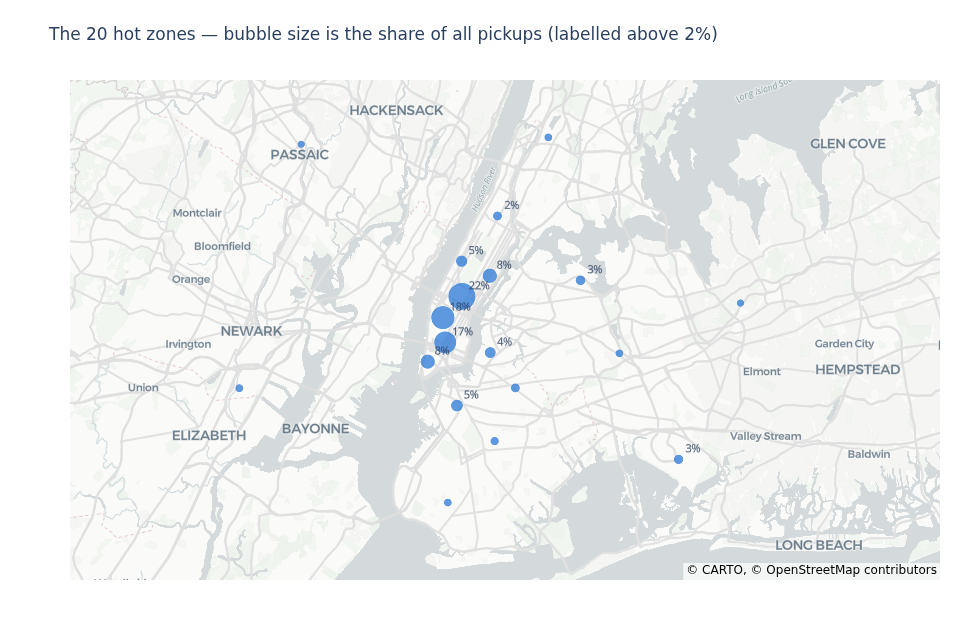

        lat      lon  pickups   share  peak hour peak day
13  40.7580 -73.9790   994119  0.2203         17      Wed
3   40.7435 -73.9962   803764  0.1781         17      Thu
8   40.7265 -73.9941   745890  0.1653         21      Sat
19  40.7722 -73.9538   357507  0.0792          7      Tue
1   40.7133 -74.0100   350922  0.0778         17      Fri
11  40.6831 -73.9836   231079  0.0512         21      Sat
0   40.7823 -73.9793   207373  0.0459          7      Mon
16  40.7195 -73.9534   188873  0.0418         22      Sat
4   40.7691 -73.8716   127947  0.0284         20      Sun
2   40.6462 -73.7827   113373  0.0251         14      Sun
6   40.8132 -73.9468    90766  0.0201         21      Sun
9   40.6952 -73.9306    88609  0.0196         21      Sun
10  40.6587 -73.9494    58495  0.0130         21      Sun
5   40.6950 -74.1808    38711  0.0086         15      Sun
15  40.8671 -73.9007    33185  0.0074         14      Sun
7   40.6164 -73.9918    31421  0.0070         19      Sun
18  40.7190 -7

In [13]:
K = 20
kmeans = KMeans(K, n_init=10, random_state=RANDOM_STATE).fit(XY)
df['zone'] = kmeans.labels_

zone_lat = np.degrees(kmeans.cluster_centers_[:, 1] / EARTH_KM)
zone_lon = np.degrees(kmeans.cluster_centers_[:, 0] / (EARTH_KM * np.cos(LAT0)))
zones = (pd.DataFrame({'lat': zone_lat, 'lon': zone_lon})
         .assign(pickups=df['zone'].value_counts().sort_index().values))
zones['share'] = zones['pickups'] / len(df)
zones['peak hour'] = df.groupby('zone')['hour'].agg(lambda s: s.value_counts().idxmax())
zones['peak day'] = df.groupby('zone')['dow'].agg(lambda s: (s.value_counts() /
                                                             df['dow'].value_counts()).idxmax())
zones['peak day'] = zones['peak day'].map(lambda d: DAYS[d][:3])

fig = go.Figure(go.Scattermap(
    lat=zones['lat'], lon=zones['lon'], mode='markers+text',
    marker=dict(size=8 + 90 * zones['share'], color=BLUE, opacity=0.75),
    text=[f'{s:.0%}' if s >= 0.02 else '' for s in zones['share']], textposition='top right',
    textfont=dict(size=11), hoverinfo='skip',
))
fig.update_layout(
    map=dict(style='carto-positron', center=dict(lat=40.735, lon=-73.94), zoom=9.6),
    title='The 20 hot zones — bubble size is the share of all pickups (labelled above 2%)',
    showlegend=False,
)
show(fig, '4_zones_map', height=640)

print(zones.sort_values('share', ascending=False).round(4).to_string())

Four zones between the Financial District and Midtown carry **64% of the demand**, led by Midtown
at 22.0%. Add the Upper East and Upper West sides and six zones of Manhattan hold **77%**. The rest
of the list is the city's other business: Downtown Brooklyn (5.1%), Williamsburg (4.2%),
**LaGuardia** (2.8%), **JFK** (2.5%), Harlem (2.0%), **Newark** (0.9%).

The `peak hour` column is where the product actually lives. It is not the same hour everywhere: the
Upper East Side zone peaks at **7h** and the East Village at **21h**, in the same city on the same
day. A single "hot zone" list for all of New York at 8 in the morning would send drivers to a
neighbourhood that will not wake up for twelve hours.

### 4.4 One caveat that has to be said out loud

In [14]:
# Re-fit the same k=20 on the same data with three other seeds. If the map is a product feature,
# the question is whether it is the same map twice.
base = kmeans
print(f'seed 42 (the map above): inertia {base.inertia_ / 1e6:.2f}M')
for seed in (1, 2, 3):
    other = KMeans(K, n_init=10, random_state=seed).fit(XY)
    d = np.sqrt(((base.cluster_centers_[:, None, :] - other.cluster_centers_[None, :, :]) ** 2).sum(-1))
    same = (d.argmin(axis=1)[base.labels_] == other.labels_).mean()
    print(f'seed {seed}: median centre shift {np.median(d.min(axis=1)) * 1000:>4.0f} m, '
          f'worst {d.min(axis=1).max() * 1000:>5.0f} m, same zone for {same:.1%} of pickups, '
          f'inertia {other.inertia_ / 1e6:.2f}M')

seed 42 (the map above): inertia 8.56M


seed 1: median centre shift  103 m, worst  3387 m, same zone for 86.6% of pickups, inertia 8.49M


seed 2: median centre shift  141 m, worst  5348 m, same zone for 83.3% of pickups, inertia 8.62M


seed 3: median centre shift  106 m, worst  3030 m, same zone for 85.1% of pickups, inertia 8.49M


**Between two runs, 13 to 17% of pickups change zone**, and one centre can move more than five
kilometres. KMeans on a smooth density has many near-equal optima and the seed picks between them —
the inertia varies by less than 2%, so the algorithm is right to be indifferent, but the *map* is
not the same map.

The consequence is operational, not statistical: **fit the zones once, freeze them, and version
them.** A driver cannot learn a geography that is re-drawn every time the job runs.

## 5. Hot zones with DBSCAN

DBSCAN asks a different question: not *"where do I put 20 pins"* but *"which points sit in a dense
neighbourhood, and which are noise"*. It needs no `k`, it finds clusters of any shape, and it can
refuse to classify a point at all — everything KMeans cannot do.

Two practical points before the results. Distances go through the **haversine** metric on radians,
because `eps` has to be a real distance and section 4.1 showed what happens otherwise. And DBSCAN
is quadratic in memory on a dataset this size, so it runs on a **100 000-pickup sample** — with
`min_samples` scaled to the sample, so that the density threshold it enforces is the same one.

In [15]:
EARTH_M = 6_371_000.0
rng = np.random.default_rng(RANDOM_STATE)


def dbscan_on_sample(n, eps_m, min_samples):
    """Fit DBSCAN on a random sample of n pickups. Returns the labels and the sampled index."""
    idx = rng.choice(len(df), n, replace=False)
    radians = np.radians(df[['Lat', 'Lon']].values[idx])
    labels = DBSCAN(eps=eps_m / EARTH_M, min_samples=min_samples, metric='haversine',
                    algorithm='ball_tree', n_jobs=-1).fit(radians).labels_
    return labels, idx


print('does the sample decide the answer? same density threshold, four sample sizes')
print(f'{"sample":>8} {"min_samples":>12} {"clusters":>9} {"noise":>7} {"biggest cluster":>16}')
for n, ms in [(50_000, 25), (100_000, 50), (200_000, 100), (400_000, 200)]:
    labels, _ = dbscan_on_sample(n, 200, ms)
    sizes = np.bincount(labels[labels >= 0])
    print(f'{n:>8,} {ms:>12} {labels.max() + 1:>9} {(labels == -1).mean():>7.2%} '
          f'{sizes.max() / n:>16.2%}'.replace(',', ' '))

does the sample decide the answer? same density threshold, four sample sizes
  sample  min_samples  clusters   noise  biggest cluster


  50 000           25        35  10.37%           74.40%


 100 000           50        31  11.14%           74.34%


 200 000          100        30  11.00%           74.28%


 400 000          200        30  11.16%           74.35%


The sample does not decide anything: from 50 000 to 400 000 pickups the answer holds at **30 to 35
clusters, 11% noise, and one cluster with three quarters of the city in it.** That last column is
not a sampling artefact, and the next cell shows it is not a parameter artefact either.

In [16]:
print(f'{"eps":>6} {"min_samples":>12} {"clusters":>9} {"noise":>7} {"biggest cluster":>16}')
for eps_m in (100, 200, 300, 500):
    for ms in (20, 50, 100):
        labels, _ = dbscan_on_sample(100_000, eps_m, ms)
        sizes = np.bincount(labels[labels >= 0])
        print(f'{eps_m:>5}m {ms:>12} {labels.max() + 1:>9} {(labels == -1).mean():>7.2%} '
              f'{sizes.max() / 100_000:>16.2%}')

   eps  min_samples  clusters   noise  biggest cluster


  100m           20       120  13.29%           73.48%


  100m           50        62  21.36%           67.08%


  100m          100        45  37.87%           48.84%


  200m           20        58   6.23%           74.89%


...

  300m           50        21   7.41%           75.35%


  300m          100        13  10.72%           74.47%


  500m           20        20   2.54%           92.68%


  500m           50        15   3.91%           89.57%


  500m          100         9   6.18%           87.69%


**Twelve settings, and the biggest cluster never drops below 49% of the sample.** Loosen `eps` and
Manhattan, Brooklyn and Queens fuse into a single 93% blob; tighten it until the blob finally
breaks apart, and DBSCAN is throwing away **38% of the demand as noise** — noise that includes,
by construction, the quieter half of the city the drivers would still like to know about.

This is not DBSCAN failing. It is DBSCAN answering correctly that **there is no empty space between
Midtown and the East Village.** Density-based clustering separates regions that are separated;
section 3 measured that this demand is one continuous ramp from the Financial District to Harlem.

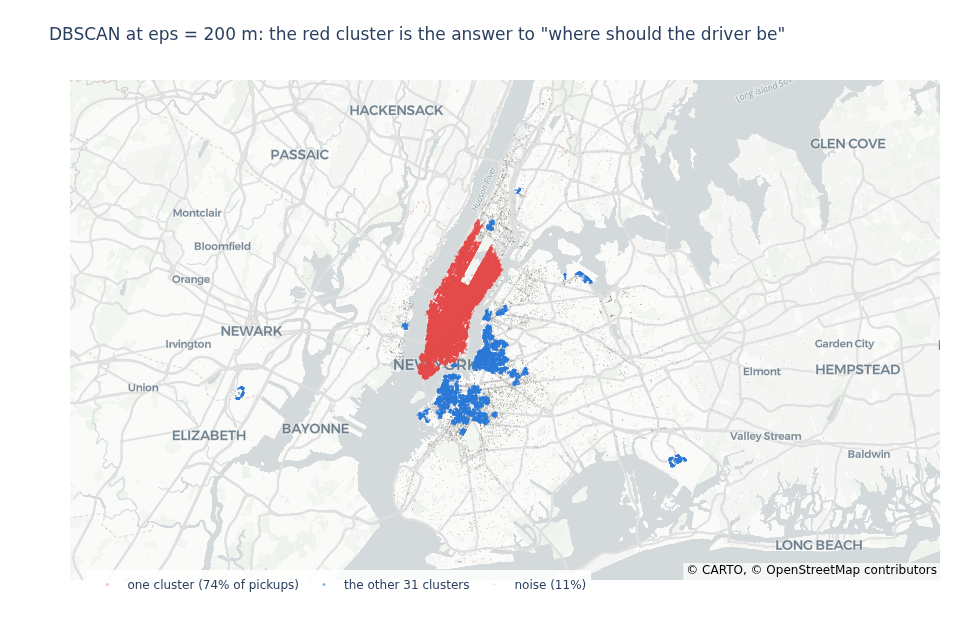

the clusters DBSCAN does isolate, largest first:
    pickups      lat      lon
c                            
6      3644  40.7175 -73.9555
11     2144  40.6935 -73.9909
7      1875  40.7718 -73.8682
5      1645  40.6457 -73.7811
3      1219  40.6858 -73.9719
12      701  40.6921 -74.1792


In [17]:
labels, idx = dbscan_on_sample(100_000, 200, 50)
sample_pts = df.iloc[idx]
sizes = pd.Series(labels[labels >= 0]).value_counts()

fig = go.Figure()
big = labels == sizes.idxmax()
fig.add_trace(go.Scattermap(lat=sample_pts['Lat'][big], lon=sample_pts['Lon'][big], mode='markers',
                            marker=dict(size=3, color=RED, opacity=0.35),
                            name=f'one cluster ({big.mean():.0%} of pickups)'))
rest = (labels >= 0) & ~big
fig.add_trace(go.Scattermap(lat=sample_pts['Lat'][rest], lon=sample_pts['Lon'][rest], mode='markers',
                            marker=dict(size=3, color=BLUE, opacity=0.55),
                            name=f'the other {sizes.size - 1} clusters'))
noise = labels == -1
fig.add_trace(go.Scattermap(lat=sample_pts['Lat'][noise], lon=sample_pts['Lon'][noise], mode='markers',
                            marker=dict(size=2, color=GREY, opacity=0.3),
                            name=f'noise ({noise.mean():.0%})'))
fig.update_layout(
    map=dict(style='carto-positron', center=dict(lat=40.735, lon=-73.94), zoom=9.6),
    title='DBSCAN at eps = 200 m: the red cluster is the answer to "where should the driver be"',
    legend=dict(orientation='h', y=0.02, x=0.02, bgcolor='rgba(255,255,255,0.85)'),
)
show(fig, '5_dbscan', height=640)

others = pd.DataFrame({'lat': sample_pts['Lat'].values, 'lon': sample_pts['Lon'].values,
                       'c': labels}).query('c >= 0 and c != @sizes.idxmax()')
print('the clusters DBSCAN does isolate, largest first:')
print(others.groupby('c').agg(pickups=('lat', 'size'), lat=('lat', 'mean'), lon=('lon', 'mean'))
      .sort_values('pickups', ascending=False).head(6).round(4).to_string())

Read the small clusters and the comparison stops being a verdict and becomes a division of labour.
What DBSCAN isolates is **exactly what is separated by water, runway or park**: Williamsburg across
the East River, Downtown Brooklyn, **JFK**, **LaGuardia**, **Newark**. It found the airports on its
own, without being told there were three, which no KMeans run can claim.

| | KMeans | DBSCAN |
|---|---|---|
| answers | where do I send N drivers | which places are dense |
| number of zones | chosen — by the 5-minute rule | emerges — 30 to 35, unusable as a list |
| Manhattan | split into 6 usable zones | one cluster, 74% of the city |
| airports | found, as 3 of the 20 zones | found, as separate clusters |
| the quiet half of the city | assigned to its nearest zone | 11% to 38% discarded as noise |
| stability | seed-dependent (section 4.4) | stable across sample sizes |

**KMeans is the right tool here** — not because it scores better on a clustering metric, but
because the question is a placement problem with a budget of drivers, and that is what it solves.
DBSCAN's contribution is the map above: it proves the demand is one continuous mass, which is the
thing that makes any "natural zone" claim false.

## 6. Do the zones move with the day of week?

The brief asks for hot zones **described per day of week**. That description is below — and so is
the measurement that says it is the wrong axis to build the feature on.

In [18]:
by_day = (df.groupby(['dow', 'zone']).size().unstack().div(df.groupby('dow').size(), axis=0))
top = zones['share'].nlargest(8).index
table = by_day[top].copy()
table.index = DAYS
table.columns = [f'{zones.loc[z, "lat"]:.3f} / {zones.loc[z, "lon"]:.3f}' for z in top]
print('share of the day\'s pickups, by zone (the 8 biggest zones, columns sum to less than 1)')
print((table * 100).round(1).to_string())

share of the day's pickups, by zone (the 8 biggest zones, columns sum to less than 1)
           40.758 / -73.979  40.743 / -73.996  40.726 / -73.994  40.772 / -73.954  40.713 / -74.010  40.683 / -73.984  40.782 / -73.979  40.720 / -73.953
Monday                 22.8              16.7              14.9               8.3               7.5               4.6               5.0               3.7
Tuesday                25.5              18.0              15.5               8.4               7.9               4.3               4.8               3.3
Wednesday              25.8              18.3              15.9               8.1               8.0               4.2               4.7               3.2
Thursday               25.0              18.8              16.3               7.8               8.0               4.3               4.5               3.3
Friday                 21.7              18.2              17.6               8.1               8.0               5.0               4.6         

In [19]:
# How far apart are two maps? Total-variation distance between the 500 m-cell distributions:
# 0 means identical, 1 means no overlap at all. Computed between every pair of days, then between
# every pair of hours, on the same cells.
def cell_distribution(mask):
    counts = cell_id[mask].value_counts()
    return counts.reindex(cell_index, fill_value=0).values / counts.sum()


cell_index = cell_id.value_counts().index
day_maps = np.array([cell_distribution((df['dow'] == d).values) for d in range(7)])
hour_maps = np.array([cell_distribution((df['hour'] == h).values) for h in range(24)])


def pair_distances(maps):
    n = len(maps)
    return np.array([0.5 * np.abs(maps[a] - maps[b]).sum()
                     for a in range(n) for b in range(a + 1, n)])


day_d, hour_d = pair_distances(day_maps), pair_distances(hour_maps)
adjacent = [0.5 * np.abs(hour_maps[h] - hour_maps[(h + 1) % 24]).sum() for h in range(24)]

print(f'distance between two maps of the city (0 = identical)')
print(f'  two days of the week : mean {day_d.mean():.3f}   worst {day_d.max():.3f}')
print(f'  two hours of the day : mean {hour_d.mean():.3f}   worst {hour_d.max():.3f}')
print(f'  two ADJACENT hours   : mean {np.mean(adjacent):.3f}')
print(f'\nthe two pairs the next paragraph names:')
print(f'  4h against 5h        : {0.5 * np.abs(hour_maps[4] - hour_maps[5]).sum():.3f}')
print(f'  Tuesday against Thu  : {0.5 * np.abs(day_maps[1] - day_maps[3]).sum():.3f}')

distance between two maps of the city (0 = identical)
  two days of the week : mean 0.125   worst 0.219
  two hours of the day : mean 0.238   worst 0.426
  two ADJACENT hours   : mean 0.098

the two pairs the next paragraph names:
  4h against 5h        : 0.146
  Tuesday against Thu  : 0.042


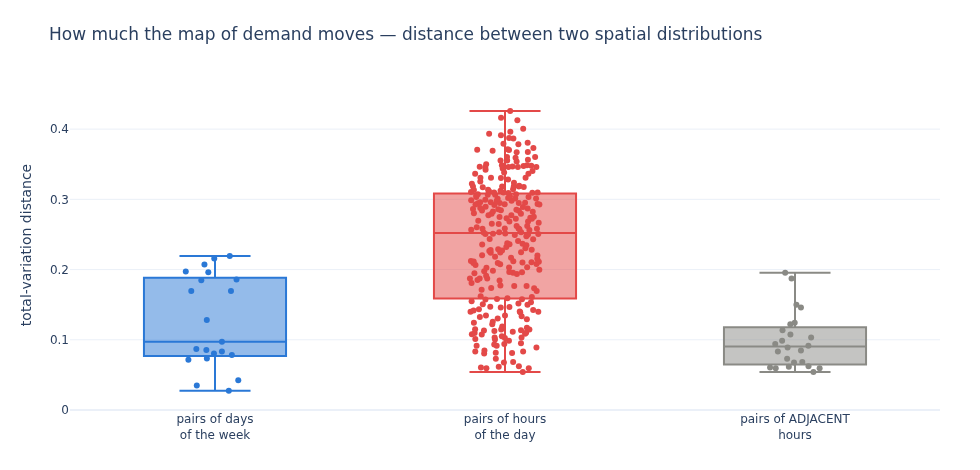

In [20]:
fig = go.Figure()
fig.add_trace(go.Box(y=day_d, name='pairs of days<br>of the week', marker_color=BLUE,
                     boxpoints='all', jitter=0.5, pointpos=0, showlegend=False))
fig.add_trace(go.Box(y=hour_d, name='pairs of hours<br>of the day', marker_color=RED,
                     boxpoints='all', jitter=0.5, pointpos=0, showlegend=False))
fig.add_trace(go.Box(y=adjacent, name='pairs of ADJACENT<br>hours', marker_color=GREY,
                     boxpoints='all', jitter=0.5, pointpos=0, showlegend=False))
fig.update_layout(
    title='How much the map of demand moves — distance between two spatial distributions',
    yaxis=dict(title='total-variation distance', range=[0, 0.47]), xaxis=dict(title=None),
)
show(fig, '6_day_vs_hour', height=470)

**The hour moves the map twice as much as the day of week** — 0.238 against 0.125 on average, 0.426
against 0.219 at the extremes. And the grey box is the one that settles the product question:
**two adjacent hours differ by 0.098, almost as much as the average pair of days.** 4h and 5h are
three times as far apart (0.146) as a Tuesday and a Thursday (0.042).

The day-of-week table above says the same thing in the zones' own units: from Monday to Sunday, the
Midtown zone moves between 25.8% and 14.9% of the day, and the East Village zone between 14.9% and
18.5%. Real, but a shuffle in the ranking — not a different city.

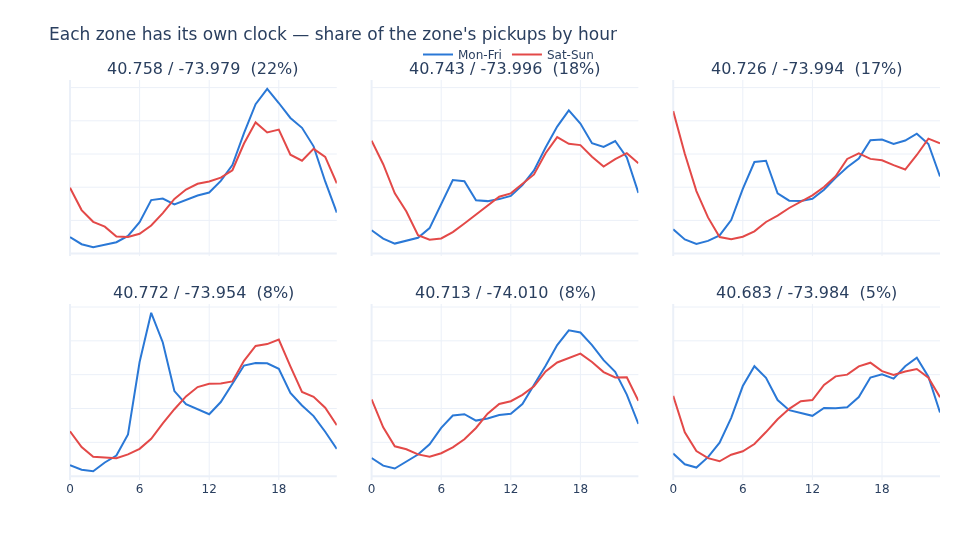

                 zone  share  peak Mon-Fri  peak Sat-Sun  Mon-Fri before noon  Sat-Sun 0h-3h
   40.758 /  -73.979  22.0%           17h           16h                22.3%           8.5%
   40.743 /  -73.996  17.8%           17h           16h                27.6%          15.8%
   40.726 /  -73.994  16.5%           21h            0h                31.8%          18.4%
   40.772 /  -73.954   7.9%            7h           18h                43.4%           5.5%


   40.713 /  -74.010   7.8%           17h           18h                26.6%           9.2%
   40.683 /  -73.984   5.1%           21h           17h                38.9%           8.8%


In [21]:
# What the app would actually ship: each zone's own clock, for the two kinds of day.
week, weekend = df['dow'] < 5, df['dow'] >= 5
fig = make_subplots(rows=2, cols=3, shared_xaxes=True, shared_yaxes=True,
                    subplot_titles=[f'{zones.loc[z, "lat"]:.3f} / {zones.loc[z, "lon"]:.3f}'
                                    f'  ({zones.loc[z, "share"]:.0%})' for z in top[:6]],
                    vertical_spacing=0.12, horizontal_spacing=0.04)
for i, z in enumerate(top[:6]):
    r, c = divmod(i, 3)
    for mask, color, name in [(week, BLUE, 'Mon-Fri'), (weekend, RED, 'Sat-Sun')]:
        s = df[mask & (df['zone'] == z)].groupby('hour').size()
        s = (s / s.sum()).reindex(range(24), fill_value=0)
        fig.add_trace(go.Scatter(x=s.index, y=s.values, mode='lines', line=dict(color=color, width=2),
                                 name=name, showlegend=(i == 0)), row=r + 1, col=c + 1)
fig.update_layout(
    title='Each zone has its own clock — share of the zone\'s pickups by hour',
    legend=dict(orientation='h', y=1.10, x=0.40),
)
fig.update_xaxes(dtick=6, title=None)
fig.update_yaxes(tickformat='.0%', showticklabels=False)
show(fig, '7_zone_clocks', height=540)

print(f'{"zone":>21} {"share":>6} {"peak Mon-Fri":>13} {"peak Sat-Sun":>13} '
      f'{"Mon-Fri before noon":>20} {"Sat-Sun 0h-3h":>14}')
for z in top[:6]:
    wd = df[week & (df['zone'] == z)].groupby('hour').size().reindex(range(24), fill_value=0)
    we = df[weekend & (df['zone'] == z)].groupby('hour').size().reindex(range(24), fill_value=0)
    wd, we = wd / wd.sum(), we / we.sum()
    print(f'{zones.loc[z, "lat"]:>9.3f} /{zones.loc[z, "lon"]:>9.3f} {zones.loc[z, "share"]:>6.1%} '
          f'{wd.idxmax():>12}h {we.idxmax():>12}h {wd[0:12].sum():>20.1%} {we[0:3].sum():>14.1%}')

Six zones, twelve curves, and no two are alike. The **Upper East Side** is the morning zone: it
peaks at **7h** on a weekday and does **43% of its business before noon**, against 22% for Midtown,
which peaks at 17h. The **East Village** is the other end of the same city — its weekend peak is at
**midnight**, and 18.4% of its Saturday-Sunday pickups fall between 0h and 3h, three times the
Upper East Side's 5.5%.

The weekday and weekend curves cross in every panel, and the peak itself moves by up to **eleven
hours** between them: the Upper East Side's 7h commute becomes an 18h evening at the weekend.

This is the deliverable, and it is indexed by *(zone, hour, weekday-or-weekend)* — not by day of
week.

## 7. What Uber should ship

**1. Twenty zones, refreshed hourly, is the product.** 20 zone centres put 85% of pickups within
1.5 km — the 5-to-7-minute wait the brief starts from. The map is in section 4.3 and the hourly
profile of each zone in section 6.

**2. Index the recommendation by the hour first, and by weekday-versus-weekend second.** The map of
demand moves twice as much between two hours of the same day as between two days of the week, and
two adjacent hours move it almost as much as an average pair of days. A feature that recommends
"Thursday's zones" is indexing on the weaker variable; the day only matters through the shape it
gives the clock — commute on weekdays, nightlife at the weekend.

**3. Freeze the zone map and version it.** Re-fitting with another seed reassigns up to 17% of
pickups and moves a centre by 5.3 km, for less than 2% of inertia. The zones are one of many
near-equal answers, so the one that ships has to be pinned, not recomputed nightly.

**4. Treat the airports separately from the city.** JFK, LaGuardia and Newark are the only three
zones that a density algorithm finds unaided, they carry 6.2% of pickups between them, and their
clock is a flight schedule rather than a working day. They deserve their own supply rule.

**5. What the file cannot answer, and what to log for the next version.** There is no drop-off
here, so nothing in this notebook knows where a driver *ends up* after a ride — a zone that is easy
to leave is worth more than one that strands the driver. There is no rider wait either: 1.5 km is a
proxy for five minutes, and the real number is in Uber's own dispatch logs. Both are cheap to
record and would turn a placement map into a real supply plan.